In [35]:
# BERT Sentiment Analysis with Evaluation on Test Set, WordClouds, and Training Report

In [36]:
import torch
import pandas as pd
import re
from torch.utils.data import Dataset
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import json
from sklearn.model_selection import train_test_split

In [37]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU device:", torch.cuda.get_device_name(0))

CUDA available: True
GPU device: NVIDIA GeForce RTX 2050


In [38]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

In [39]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [40]:
# Or modify your plotting function:
def plot_sentiment_distribution(df, title):
    # Map lowercase to capitalized
    df = df.copy()
    df['Sentiment'] = df['Sentiment'].str.capitalize()
    
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df['Sentiment'], palette='coolwarm',
                 order=['Positive', 'Neutral', 'Negative'])
    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

In [41]:
def generate_wordcloud(words, title):
    if not words:
        print(f"Warning: No words available for {title}.")
        return
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

In [42]:
def plot_top_words(word_frequencies, sentiment):
    if len(word_frequencies) == 0:
        print(f"No top words found for {sentiment}")
        return
    top_words = sorted(word_frequencies.items(), key=lambda x: x[1], reverse=True)[:10]
    words, freq = zip(*top_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(freq), y=list(words), palette='coolwarm')
    plt.title(f"Top Words for {sentiment} Sentiment")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

In [43]:
original_train_df = pd.read_csv("train_dataset_sentiment_textblob.csv")  # Renamed from train_df
test_df = pd.read_csv("test_dataset_sentiment_textblob.csv")

original_train_df = pd.read_csv("train_dataset_sentiment_textblob_1000.csv")  # Renamed from train_df
test_df = pd.read_csv("test_dataset_sentiment_textblob_1000.csv")

original_train_df = pd.read_csv("train_dataset_sentiment_textblob_3000.csv")  # Renamed from train_df
test_df = pd.read_csv("test_dataset_sentiment_textblob_3000.csv")

original_train_df = pd.read_csv("train_dataset_sentiment_textblob_5000.csv")  # Renamed from train_df
test_df = pd.read_csv("test_dataset_sentiment_textblob_5000.csv")


In [44]:

# Display numerical sentiment distribution (counts)
print("\n📊 Sentiment Counts (Original Train):")
print(original_train_df['Sentiment'].value_counts())
print("\n📊 Sentiment Counts (Test):")
print(test_df['Sentiment'].value_counts())



📊 Sentiment Counts (Original Train):
Sentiment
Neutral     4694
Positive    1813
Negative     589
Name: count, dtype: int64

📊 Sentiment Counts (Test):
Sentiment
Neutral     1187
Positive     443
Negative     144
Name: count, dtype: int64


In [45]:
# Split original training data into train and validation sets
train_df, val_df = train_test_split(
    original_train_df, 
    test_size=0.2, 
    random_state=42,
    stratify=original_train_df['Sentiment']  # Important for maintaining class balance
)
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("\nTrain sentiment counts:")
print(train_df['Sentiment'].value_counts())

Train samples: 5676
Validation samples: 1420

Train sentiment counts:
Sentiment
Neutral     3755
Positive    1450
Negative     471
Name: count, dtype: int64


In [46]:
# Text preprocessing (applied to all datasets)
for df in [train_df, val_df, test_df]:
    df['Final_Comment'] = df['Final_Comment'].astype(str).str.lower()
    df['Sentiment'] = df['Sentiment'].str.lower()

In [47]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
for df in [train_df, val_df, test_df]:
    df['Sentiment_Label'] = df['Sentiment'].map(label_map)

In [48]:
# Initialize tokenizer and create datasets
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\huggingface_hub\file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [49]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

In [50]:
# Create all three datasets
train_dataset = SentimentDataset(train_df['Final_Comment'].tolist(), train_df['Sentiment_Label'].tolist())
val_dataset = SentimentDataset(val_df['Final_Comment'].tolist(), val_df['Sentiment_Label'].tolist()) 
test_dataset = SentimentDataset(test_df['Final_Comment'].tolist(), test_df['Sentiment_Label'].tolist())

In [51]:
# Model initialization
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\huggingface_hub\file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [52]:
# Training arguments (unchanged)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    load_best_model_at_end=True
)

In [53]:
training_history = {}

In [54]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

In [55]:
# Modified Trainer with validation set
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Now using validation set for evaluation during training
    compute_metrics=compute_metrics
)

In [56]:
# Training process and capture epoch-wise loss
train_result = trainer.train()

# Extract loss per epoch from logs
log_history = trainer.state.log_history
train_losses = []
val_losses = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_losses.append((log['epoch'], log['loss']))
    if 'eval_loss' in log and 'epoch' in log:
        val_losses.append((log['epoch'], log['eval_loss']))

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.312465,0.917606
2,0.351700,0.165405,0.950000
3,0.139800,0.208132,0.952817
4,0.139800,0.233115,0.959155
5,0.056300,0.237308,0.957042


In [57]:
# Function to save predictions
def save_predictions(dataset, original_df, dataset_name):
    predictions = trainer.predict(dataset)
    pred_labels = predictions.predictions.argmax(axis=1)
    probabilities = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
    
    results_df = original_df.copy()
    results_df['BERT_Predicted_Label'] = pred_labels
    results_df['BERT_Predicted_Sentiment'] = results_df['BERT_Predicted_Label'].map(
        {0: 'negative', 1: 'neutral', 2: 'positive'})
    
    results_df['BERT_Negative_Prob'] = probabilities[:, 0]
    results_df['BERT_Neutral_Prob'] = probabilities[:, 1]
    results_df['BERT_Positive_Prob'] = probabilities[:, 2]
    
    if 'Sentiment_Label' in results_df.columns:
        results_df['Correct_Prediction'] = results_df['Sentiment_Label'] == results_df['BERT_Predicted_Label']
    
    filename = f"bert_predictions_{dataset_name}(TextBlob).csv"
    results_df.to_csv(filename, index=False)
    print(f"✅ Saved {dataset_name} predictions to {filename}")
    return results_df


# Function to save predictions
def save_predictions(dataset, original_df, dataset_name):
    predictions = trainer.predict(dataset)
    pred_labels = predictions.predictions.argmax(axis=1)
    probabilities = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
    
    results_df = original_df.copy()
    results_df['BERT_Predicted_Label'] = pred_labels
    results_df['BERT_Predicted_Sentiment'] = results_df['BERT_Predicted_Label'].map(
        {0: 'negative', 1: 'neutral', 2: 'positive'})
    
    results_df['BERT_Negative_Prob'] = probabilities[:, 0]
    results_df['BERT_Neutral_Prob'] = probabilities[:, 1]
    results_df['BERT_Positive_Prob'] = probabilities[:, 2]
    
    if 'Sentiment_Label' in results_df.columns:
        results_df['Correct_Prediction'] = results_df['Sentiment_Label'] == results_df['BERT_Predicted_Label']
    
    filename = f"bert_predictions_{dataset_name}(TextBlob)_1000.csv"
    results_df.to_csv(filename, index=False)
    print(f"✅ Saved {dataset_name} predictions to {filename}")
    return results_df
    

# Function to save predictions
def save_predictions(dataset, original_df, dataset_name):
    predictions = trainer.predict(dataset)
    pred_labels = predictions.predictions.argmax(axis=1)
    probabilities = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
    
    results_df = original_df.copy()
    results_df['BERT_Predicted_Label'] = pred_labels
    results_df['BERT_Predicted_Sentiment'] = results_df['BERT_Predicted_Label'].map(
        {0: 'negative', 1: 'neutral', 2: 'positive'})
    
    results_df['BERT_Negative_Prob'] = probabilities[:, 0]
    results_df['BERT_Neutral_Prob'] = probabilities[:, 1]
    results_df['BERT_Positive_Prob'] = probabilities[:, 2]
    
    if 'Sentiment_Label' in results_df.columns:
        results_df['Correct_Prediction'] = results_df['Sentiment_Label'] == results_df['BERT_Predicted_Label']
    
    filename = f"bert_predictions_{dataset_name}(TextBlob)_3000.csv"
    results_df.to_csv(filename, index=False)
    print(f"✅ Saved {dataset_name} predictions to {filename}")
    return results_df
    

# Function to save predictions
def save_predictions(dataset, original_df, dataset_name):
    predictions = trainer.predict(dataset)
    pred_labels = predictions.predictions.argmax(axis=1)
    probabilities = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
    
    results_df = original_df.copy()
    results_df['BERT_Predicted_Label'] = pred_labels
    results_df['BERT_Predicted_Sentiment'] = results_df['BERT_Predicted_Label'].map(
        {0: 'negative', 1: 'neutral', 2: 'positive'})
    
    results_df['BERT_Negative_Prob'] = probabilities[:, 0]
    results_df['BERT_Neutral_Prob'] = probabilities[:, 1]
    results_df['BERT_Positive_Prob'] = probabilities[:, 2]
    
    if 'Sentiment_Label' in results_df.columns:
        results_df['Correct_Prediction'] = results_df['Sentiment_Label'] == results_df['BERT_Predicted_Label']
    
    filename = f"bert_predictions_{dataset_name}(TextBlob)_5000.csv"
    results_df.to_csv(filename, index=False)
    print(f"✅ Saved {dataset_name} predictions to {filename}")
    return results_df

In [58]:

# Generate and save predictions
print("\nGenerating predictions for all datasets...")
train_results = save_predictions(train_dataset, train_df, "train")
val_results = save_predictions(val_dataset, val_df, "validation")
test_results = save_predictions(test_dataset, test_df, "test")

# Final evaluation on test set (only done once at the end)
test_metrics = trainer.evaluate(test_dataset)
print("Final Test Evaluation:", test_metrics)


Generating predictions for all datasets...


✅ Saved train predictions to bert_predictions_train(TextBlob).csv


✅ Saved validation predictions to bert_predictions_validation(TextBlob).csv


✅ Saved test predictions to bert_predictions_test(TextBlob).csv


Final Test Evaluation: {'eval_loss': 0.1727936714887619, 'eval_accuracy': 0.9470124013528749, 'eval_runtime': 7.1712, 'eval_samples_per_second': 247.379, 'eval_steps_per_second': 7.809, 'epoch': 5.0}


In [59]:
training_history['train_metrics'] = train_result.metrics
training_history['val_metrics'] = trainer.evaluate(val_dataset)
training_history['test_metrics'] = test_metrics

# Save loss values per epoch for chart visualization
training_history['loss_curve'] = {
    "train_loss": [{"epoch": e, "loss": l} for e, l in train_losses],
    "val_loss": [{"epoch": e, "loss": l} for e, l in val_losses]
}


# Save training report
with open("bert_training_report_textblob.json", "w") as f:
    json.dump(training_history, f, indent=2)

In [60]:
# Generate predictions on test set
predictions = trainer.predict(test_dataset)
pred_labels = predictions.predictions.argmax(axis=1)
true_labels = test_df['Sentiment_Label'].tolist()

In [61]:
# Classification report
report_dict = classification_report(true_labels, pred_labels, 
                                  target_names=['Negative', 'Neutral', 'Positive'], 
                                  output_dict=True)
report_text = classification_report(true_labels, pred_labels, 
                                   target_names=['Negative', 'Neutral', 'Positive'])



# Save report to JSON
with open("classification_report_bert_textblob.json", "w") as f:
    json.dump(report_dict, f, indent=2)

In [62]:
# Print clean inline report
print("\n📄 Classification Report (Text Version):")
print(report_text)


📄 Classification Report (Text Version):
              precision    recall  f1-score   support

    Negative       0.86      0.92      0.89       144
     Neutral       0.97      0.96      0.96      1187
    Positive       0.92      0.93      0.93       443

    accuracy                           0.95      1774
   macro avg       0.92      0.94      0.93      1774
weighted avg       0.95      0.95      0.95      1774



In [63]:
# Create evaluation dataframe
df_eval = pd.DataFrame({
    'Actual': true_labels,
    'Predicted': pred_labels
})
df_eval['Sentiment'] = df_eval['Predicted'].map({0: 'Negative', 1: 'Neutral', 2: 'Positive'})


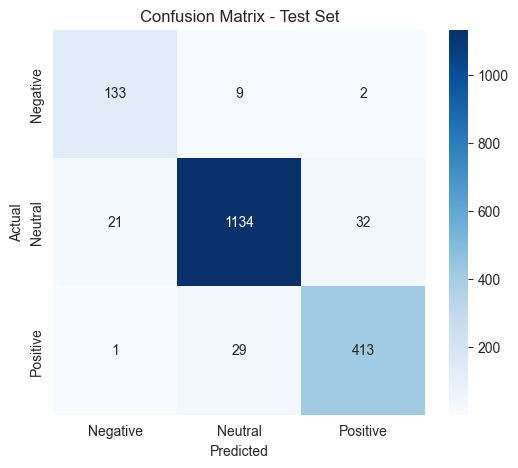

C:\Users\amirb\AppData\Local\Temp\ipykernel_25448\1310884455.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm',


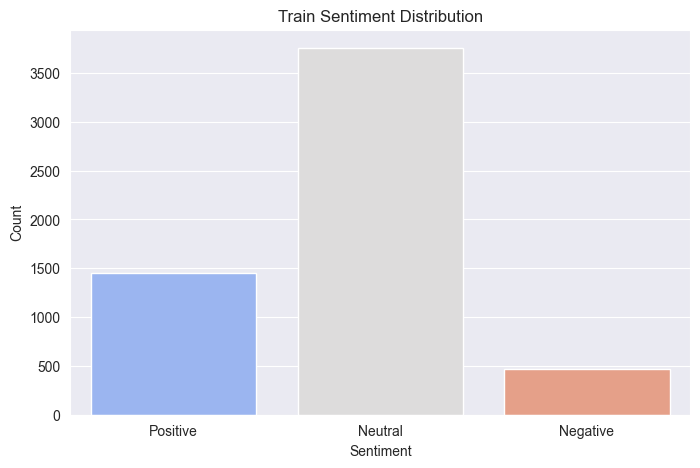

C:\Users\amirb\AppData\Local\Temp\ipykernel_25448\1310884455.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm',


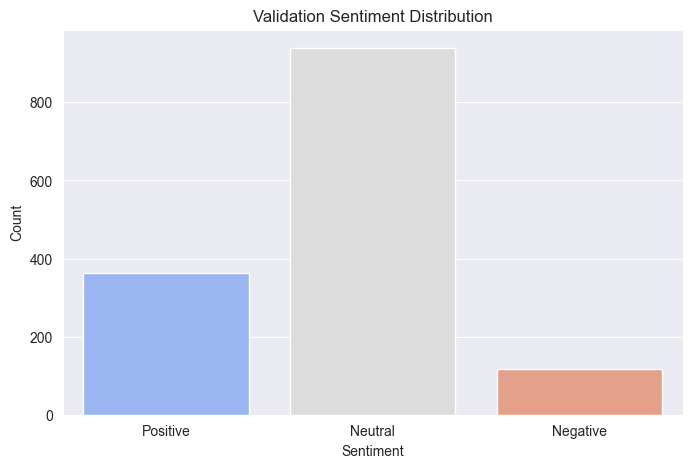

C:\Users\amirb\AppData\Local\Temp\ipykernel_25448\1310884455.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm',


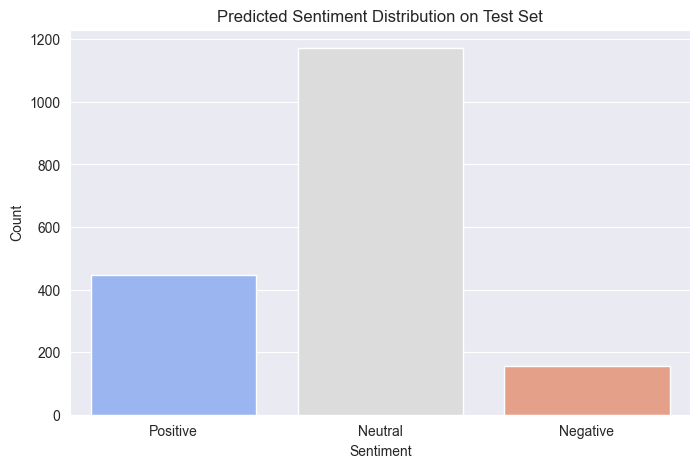

In [64]:
# Visualizations
plot_confusion_matrix(true_labels, pred_labels, "Confusion Matrix - Test Set")
plot_sentiment_distribution(train_df, "Train Sentiment Distribution")
plot_sentiment_distribution(val_df, "Validation Sentiment Distribution")  # Added validation distribution
plot_sentiment_distribution(df_eval, "Predicted Sentiment Distribution on Test Set")


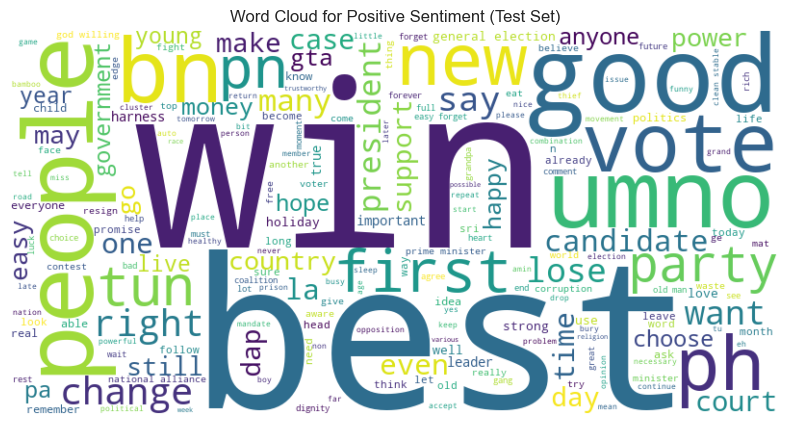

C:\Users\amirb\AppData\Local\Temp\ipykernel_25448\1319581252.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freq), y=list(words), palette='coolwarm')


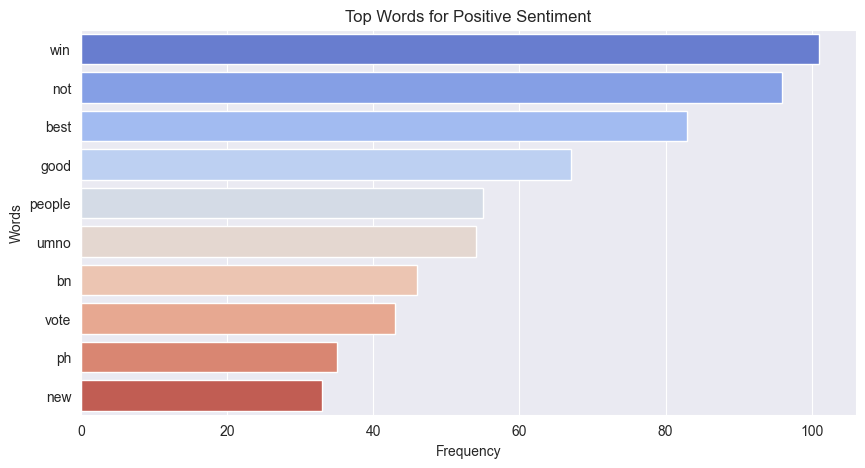

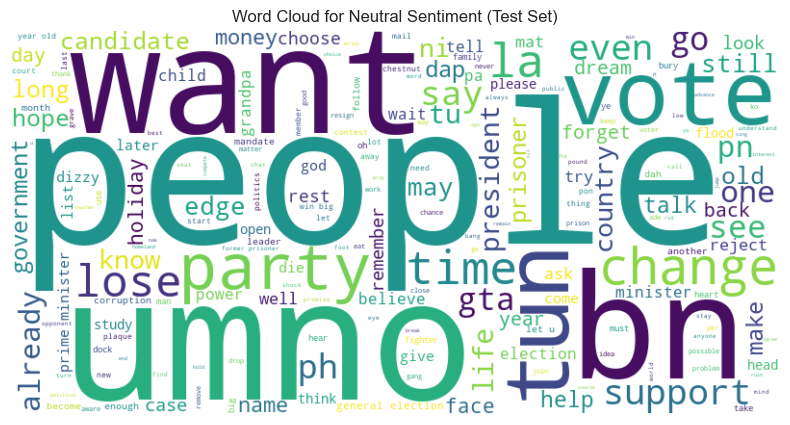

C:\Users\amirb\AppData\Local\Temp\ipykernel_25448\1319581252.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freq), y=list(words), palette='coolwarm')


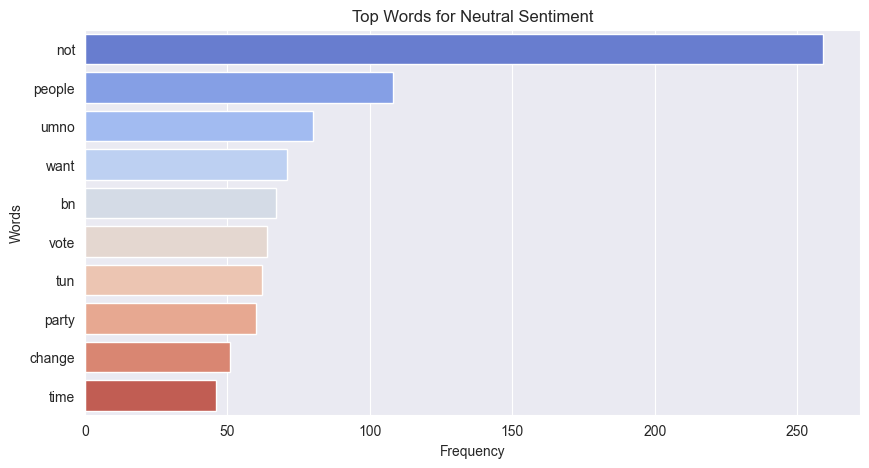

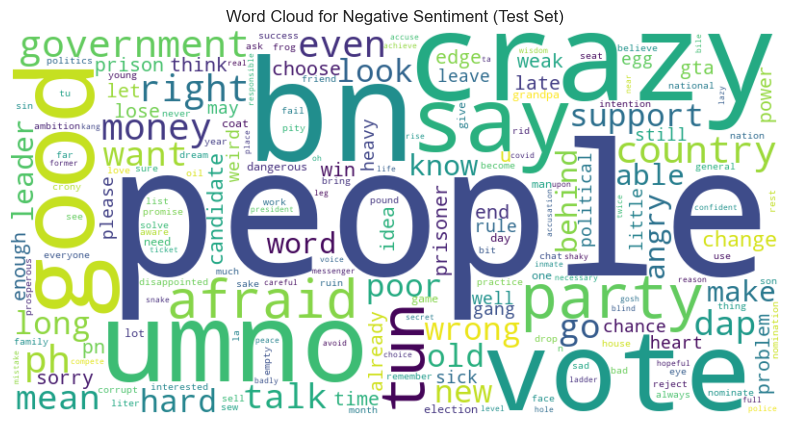

C:\Users\amirb\AppData\Local\Temp\ipykernel_25448\1319581252.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freq), y=list(words), palette='coolwarm')


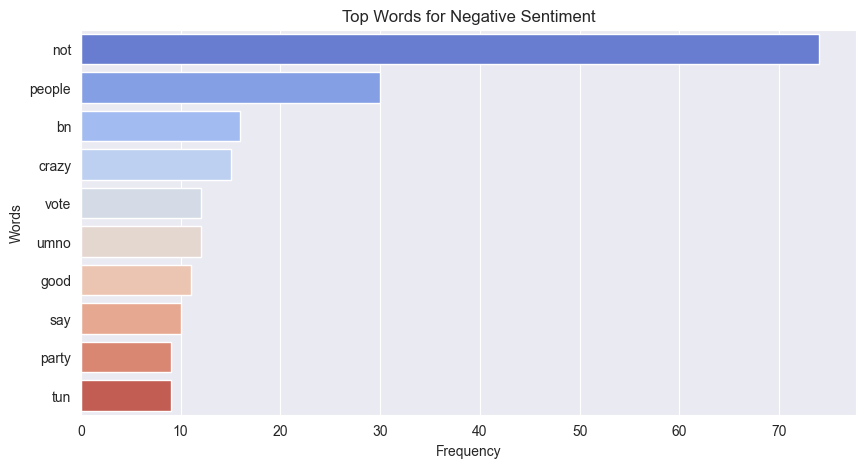

In [65]:
# Word clouds and top words analysis
text_by_sentiment = {'Positive': [], 'Neutral': [], 'Negative': []}
for sentiment, comment in zip(df_eval['Sentiment'], test_df['Final_Comment']):
    words = preprocess_text(comment).split()
    text_by_sentiment[sentiment].extend(words)

for sentiment in ['Positive', 'Neutral', 'Negative']:
    generate_wordcloud(text_by_sentiment[sentiment], f"Word Cloud for {sentiment} Sentiment (Test Set)")
    plot_top_words(Counter(text_by_sentiment[sentiment]), sentiment)

In [66]:
# === New Code: Combine the train & validation prediction CSVs into one dataset ===
train_pred_df = pd.read_csv("bert_predictions_train(TextBlob).csv")
val_pred_df   = pd.read_csv("bert_predictions_validation(TextBlob).csv")

combined_tv = pd.concat([train_pred_df, val_pred_df], ignore_index=True)
combined_tv_filename = "bert_predictions_train_validation(TextBlob).csv"
combined_tv.to_csv(combined_tv_filename, index=False)
print(f"✅ Combined train & validation predictions saved as '{combined_tv_filename}'")

✅ Combined train & validation predictions saved as 'bert_predictions_train_validation(TextBlob).csv'


In [67]:
# Save model
model.save_pretrained("./bert_finetuned_textblob_model")
tokenizer.save_pretrained("./bert_finetuned_textblob_model")
print("✅ Model and tokenizer saved.")

✅ Model and tokenizer saved.


# Save model
model.save_pretrained("./bert_finetuned_textblob_model")
tokenizer.save_pretrained("./bert_finetuned_textblob_model")
print("✅ Model and tokenizer saved.")

# === New Code: Combine the train & validation prediction CSVs into one dataset ===
train_pred_df = pd.read_csv("bert_predictions_train(TextBlob).csv")
val_pred_df   = pd.read_csv("bert_predictions_validation(TextBlob).csv")

combined_tv = pd.concat([train_pred_df, val_pred_df], ignore_index=True)
combined_tv_filename = "bert_predictions_train_validation(TextBlob).csv"
combined_tv.to_csv(combined_tv_filename, index=False)
print(f"✅ Combined train & validation predictions saved as '{combined_tv_filename}'")

# === New Code: Combine the train & validation prediction CSVs into one dataset ===
train_pred_df = pd.read_csv("bert_predictions_train(TextBlob)_1000.csv")
val_pred_df   = pd.read_csv("bert_predictions_validation(TextBlob)_1000.csv")

combined_tv = pd.concat([train_pred_df, val_pred_df], ignore_index=True)
combined_tv_filename = "bert_predictions_train_validation(TextBlob)_1000.csv"
combined_tv.to_csv(combined_tv_filename, index=False)
print(f"✅ Combined train & validation predictions saved as '{combined_tv_filename}'")

# === New Code: Combine the train & validation prediction CSVs into one dataset ===
train_pred_df = pd.read_csv("bert_predictions_train(TextBlob)_3000.csv")
val_pred_df   = pd.read_csv("bert_predictions_validation(TextBlob)_3000.csv")

combined_tv = pd.concat([train_pred_df, val_pred_df], ignore_index=True)
combined_tv_filename = "bert_predictions_train_validation(TextBlob)_3000.csv"
combined_tv.to_csv(combined_tv_filename, index=False)
print(f"✅ Combined train & validation predictions saved as '{combined_tv_filename}'")

# === New Code: Combine the train & validation prediction CSVs into one dataset ===
train_pred_df = pd.read_csv("bert_predictions_train(TextBlob)_5000.csv")
val_pred_df   = pd.read_csv("bert_predictions_validation(TextBlob)_5000.csv")

combined_tv = pd.concat([train_pred_df, val_pred_df], ignore_index=True)
combined_tv_filename = "bert_predictions_train_validation(TextBlob)_5000.csv"
combined_tv.to_csv(combined_tv_filename, index=False)
print(f"✅ Combined train & validation predictions saved as '{combined_tv_filename}'")

test_pred_df = pd.read_csv("bert_predictions_test(TextBlob).csv")

combined_all = pd.concat([combined_tv, test_pred_df], ignore_index=True)
combined_all_filename = "bert_predictions_all(TextBlob).csv"
combined_all.to_csv(combined_all_filename, index=False)
print(f"✅ Combined train+validation+test predictions saved as '{combined_all_filename}'")